# Cluster Steam Games using a Matrix of Game x Tag

Construct a game-tag matrix from SteamSpy community tags, then cluster using K-Means to identify natural market segments.

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
df = pd.read_csv("steam.csv")
print(df.shape)
df.head(3)

(27075, 18)


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99


## Build the Game x Tag Matrix

In [4]:
# Find the top 50 most common community tags across all games
all_tags = []
for row in df["steamspy_tags"].dropna():
    all_tags.extend(row.split(";"))

tag_counts = Counter(all_tags)
top_tags = [tag for tag, _ in tag_counts.most_common(50)]
print(f"Top 5 tags: {top_tags[:5]}")

Top 5 tags: ['Indie', 'Action', 'Casual', 'Adventure', 'Strategy']


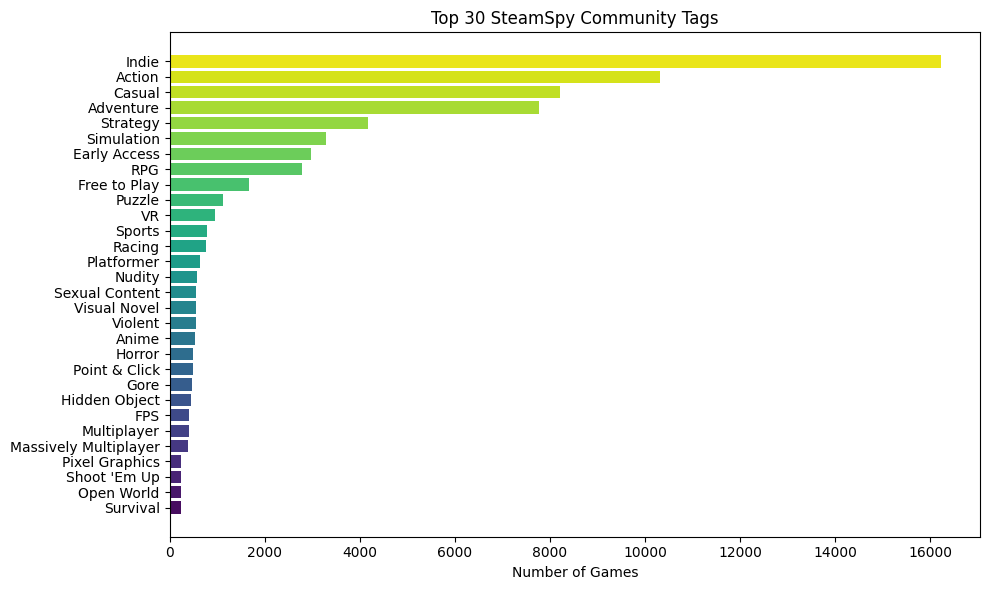

In [5]:
# Plot the tag distribution
top30 = tag_counts.most_common(30)
tags_30, counts_30 = zip(*top30)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tags_30[::-1], counts_30[::-1], color=sns.color_palette("viridis", 30))
ax.set_xlabel("Number of Games")
ax.set_title("Top 30 SteamSpy Community Tags")
plt.tight_layout()
plt.show()

In [6]:
# Build a game x tag binary matrix (1 if game has that tag, 0 otherwise)
from sklearn.preprocessing import MultiLabelBinarizer

df["tags_list"] = df["steamspy_tags"].fillna("").apply(lambda x: x.split(";") if x else [])

mlb = MultiLabelBinarizer(classes=top_tags)
tag_matrix = mlb.fit_transform(df["tags_list"])

tag_df = pd.DataFrame(tag_matrix, columns=top_tags, index=df["name"])
tag_df

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['1980s', "1990's", '2.5D', '2D Fighter', '360 Video', '3D', '3D Platformer', '3D Vision', '4 Player Local', '4X', '6DOF', 'Abstract', 'Action RPG', 'Action-Adventure', 'Agriculture', 'Aliens', 'Alternate History', 'America', 'Animation & Modeling', 'Arena Shooter', 'Assassin', 'Atmospheric', 'Audio Production', 'BMX', 'Base-Building', 'Baseball', 'Basketball', 'Batman', 'Battle Royale', "Beat 'em up", 'Beautiful', 'Benchmark', 'Bikes', 'Blood', 'Board Game', 'Bowling', 'Building', 'Bullet Hell', 'Bullet Time', 'CRPG', 'Capitalism', 'Cartoon', 'Cartoony', 'Cats', 'Character Action Game', 'Character Customization', 'Chess', 'Choices Matter', 'Choose Your Own Adventure', 'Cinematic', 'City Builder', 'Class-Based', 'Clicker', 'Cold War', 'Colorful', 'Comedy', 'Comic Book', 'Competitive', 'Controller', 'Conversation', 'Crafting', 'Crime', 'Cult Classic', 'Cute', 'Cyberpunk', 'Cycling

,Indie,Action,Casual,Adventure,Strategy,Simulation,Early Access,RPG,Free to Play,Puzzle,...,Singleplayer,Story Rich,Zombies,Sci-fi,Utilities,World War II,Great Soundtrack,Co-op,Match 3,Fighting
name,,,,,,,,,,,,,,,,,,,,,
Counter-Strike,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Team Fortress Classic,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Day of Defeat,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Deathmatch Classic,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Half-Life: Opposing Force,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Room of Pandora,1,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Cyber Gun,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Super Star Blast,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Check a known game — Elden Ring-adjacent titles should have Action, RPG, Open World
tag_df[tag_df.index.str.contains("Dark Souls", case=False)].loc[:, ["Action", "RPG", "Open World", "Indie", "Casual"]]

,Action,RPG,Open World,Indie,Casual
name,,,,,
DARK SOULS™ II,0,1,0,0,0
DARK SOULS™ II: Scholar of the First Sin,0,1,0,0,0
DARK SOULS™ III,0,1,0,0,0
DARK SOULS™: REMASTERED,1,0,0,0,0


## Add Numeric Features

Similarity is measured using **cosine distance** on a hybrid feature vector:
- Binary tag presence (top 50 SteamSpy tags, weighted 2x)
- Normalized: positive review ratio, log playtime, log price, log achievements

Cosine is chosen because tag vectors are sparse — two games sharing genre identity should be similar regardless of how many total tags they have.

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Derived numeric features
df["positive_ratio"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"] + 1)
df["log_playtime"]   = np.log1p(df["average_playtime"])
df["log_price"]      = np.log1p(df["price"])
df["log_achievements"] = np.log1p(df["achievements"])

numeric_cols = ["positive_ratio", "log_playtime", "log_price", "log_achievements"]
scaler = MinMaxScaler()
numeric_scaled = scaler.fit_transform(df[numeric_cols])

# Combine: tags weighted 2x since they carry more semantic signal
feature_matrix = np.hstack([tag_matrix * 2.0, numeric_scaled])
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (27075, 54)


## Select k with Elbow Method + Silhouette Score

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Subsample for speed during k search
np.random.seed(42)
sample_idx = np.random.choice(len(feature_matrix), size=3000, replace=False)
X_sample = feature_matrix[sample_idx]

inertias, sil_scores = [], []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, metric="cosine", sample_size=1000))
    print(f"k={k}: silhouette={sil_scores[-1]:.4f}")

k=2: silhouette=0.2198
k=3: silhouette=0.2449
k=4: silhouette=0.2605
k=5: silhouette=0.2658
k=6: silhouette=0.2382
k=7: silhouette=0.2276
k=8: silhouette=0.2521
k=9: silhouette=0.2482
k=10: silhouette=0.1852
k=11: silhouette=0.2022


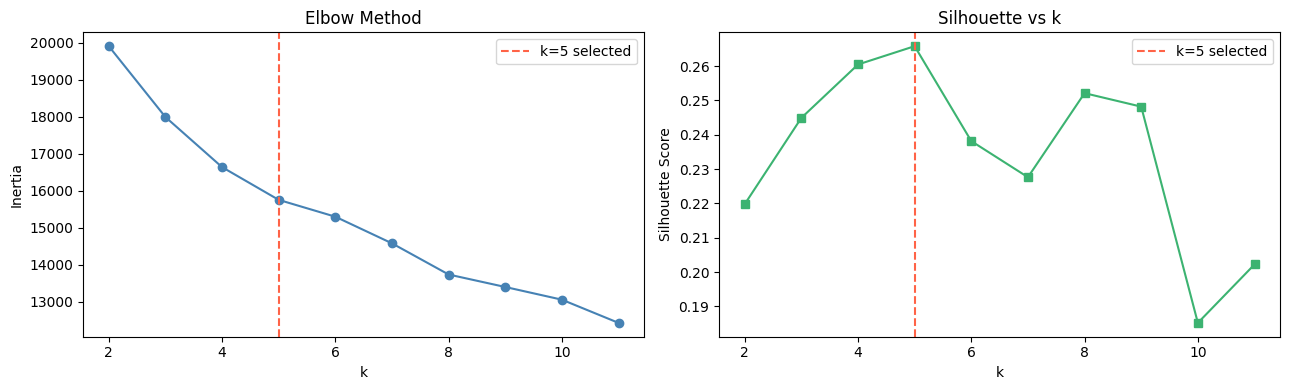

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, "o-", color="steelblue")
ax1.axvline(x=5, color="tomato", linestyle="--", label="k=5 selected")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow Method"); ax1.legend()

ax2.plot(list(k_range), sil_scores, "s-", color="mediumseagreen")
ax2.axvline(x=5, color="tomato", linestyle="--", label="k=5 selected")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette Score"); ax2.set_title("Silhouette vs k"); ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# k=5 selected: silhouette peaks here (0.266), elbow flattens after k=5
k = 5

## Apply K-Means (k=5)

In [12]:
cluster_model = KMeans(n_clusters=k, random_state=42, n_init=15, max_iter=300)

In [13]:
cluster_model.fit(feature_matrix)

KMeans(n_clusters=5, n_init=15, random_state=42)

In [14]:
cluster_labels = cluster_model.predict(feature_matrix)
df["cluster"] = cluster_labels

In [15]:
df["cluster"].value_counts()

,count
cluster,
2,7147
4,6655
3,5132
1,4492
0,3649


In [16]:
# Print cluster size + top tags + sample games
for cluster, games in df.groupby("cluster"):
    tags = []
    for row in games["steamspy_tags"].dropna():
        tags.extend(row.split(";"))
    top5 = [t for t, _ in Counter(tags).most_common(5)]
    print(f"\nCluster {cluster} | n={games.shape[0]} | top tags: {top5}")
    for _, game in games.sample(3, random_state=42).iterrows():
        print(f"  {game['name']} | ${game['price']:.2f} | pos_ratio={game['positive_ratio']:.2f}")


Cluster 0 | n=3649 | top tags: ['Action', 'Adventure', 'Early Access', 'Casual', 'Strategy']
  Uncrewed | $8.99 | pos_ratio=0.75
  Pew Pew Rocket | $1.69 | pos_ratio=0.91
  Border Officer | $7.19 | pos_ratio=0.69

Cluster 1 | n=4492 | top tags: ['Casual', 'Indie', 'Strategy', 'Simulation', 'Puzzle']
  Toki Tori 2+ | $10.99 | pos_ratio=0.84
  There Is A Genie In My Szechuan Sauce | $1.69 | pos_ratio=0.77
  Old School 8-in-1 bundle | $5.59 | pos_ratio=0.50

Cluster 2 | n=7147 | top tags: ['Indie', 'Strategy', 'Simulation', 'RPG', 'Early Access']
  Dunk It (VR Basketball) | $0.79 | pos_ratio=0.30
  Battlefleet Gothic: Armada 2 | $34.99 | pos_ratio=0.73
  LIGHTNING RETURNS™: FINAL FANTASY® XIII | $12.99 | pos_ratio=0.80

Cluster 3 | n=5132 | top tags: ['Indie', 'Action', 'Casual', 'Early Access', 'Strategy']
  Snipiyo / スナイピヨ | $1.69 | pos_ratio=0.33
  Darwin's Demons | $2.09 | pos_ratio=0.86
  Tesla vs Lovecraft | $10.99 | pos_ratio=0.89

Cluster 4 | n=6655 | top tags: ['Adventure', 'Ind

## Visualize Clusters

In [17]:
from sklearn.decomposition import PCA

# PCA down to 2D for visualization (sample 3000 for speed)
np.random.seed(42)
viz_idx = np.random.choice(len(feature_matrix), size=3000, replace=False)
X_2d = PCA(n_components=2, random_state=42).fit_transform(feature_matrix[viz_idx])
labels_viz = df["cluster"].values[viz_idx]

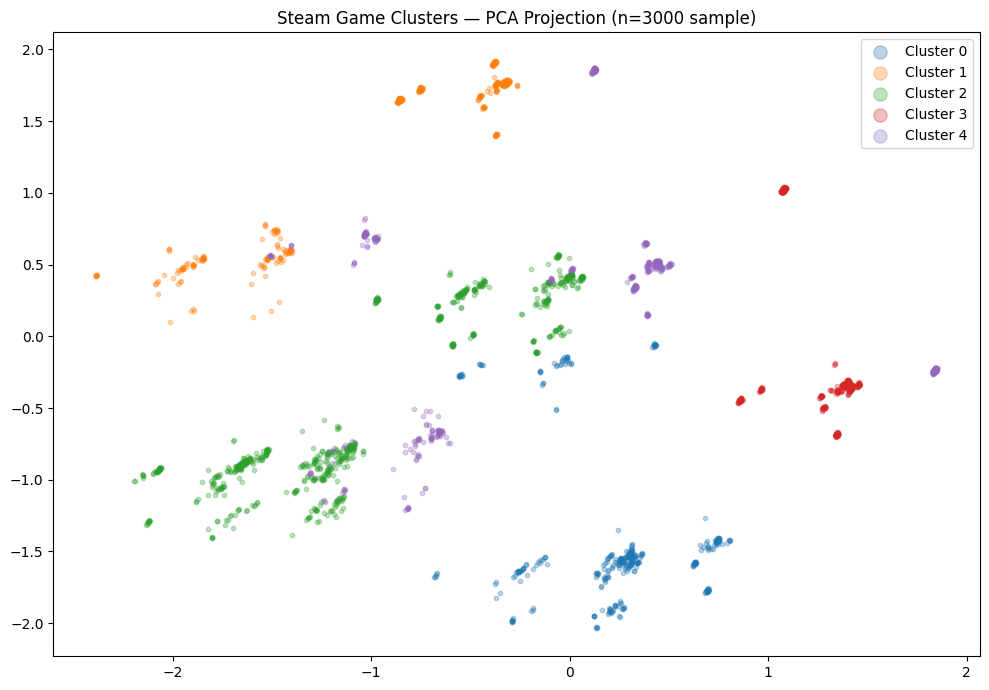

In [18]:
palette = sns.color_palette("tab10", k)

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(k):
    mask = labels_viz == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=palette[c], alpha=0.3, s=10, label=f"Cluster {c}")

ax.set_title("Steam Game Clusters — PCA Projection (n=3000 sample)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

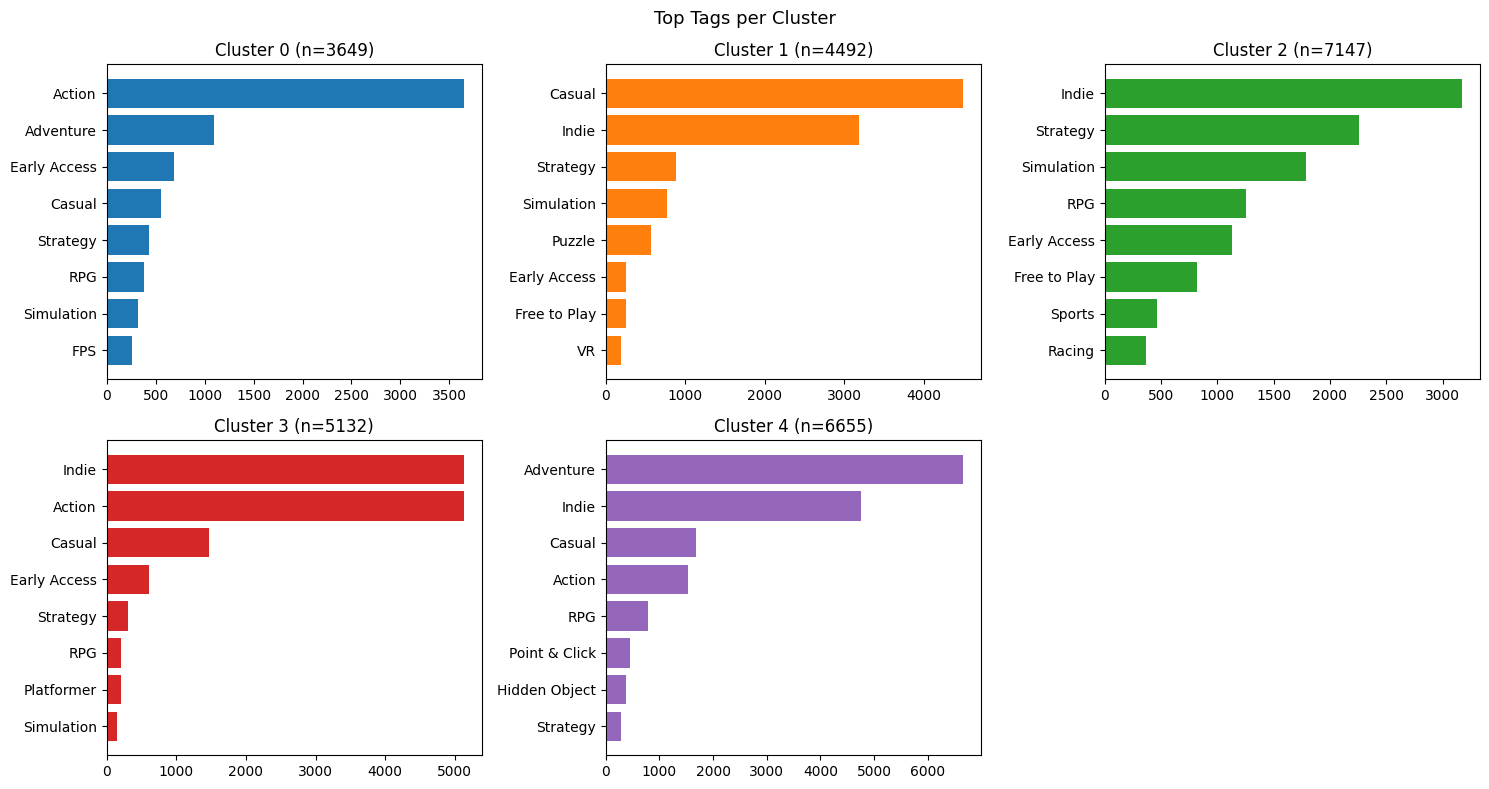

In [19]:
# Top tags per cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for c in range(k):
    cdf = df[df["cluster"] == c]
    tags = []
    for row in cdf["steamspy_tags"].dropna():
        tags.extend(row.split(";"))
    top = Counter(tags).most_common(8)
    tag_names, tag_cnts = zip(*top)
    axes[c].barh(tag_names[::-1], tag_cnts[::-1], color=palette[c])
    axes[c].set_title(f"Cluster {c} (n={len(cdf)})")

axes[k].axis("off")
plt.suptitle("Top Tags per Cluster", fontsize=13)
plt.tight_layout()
plt.show()

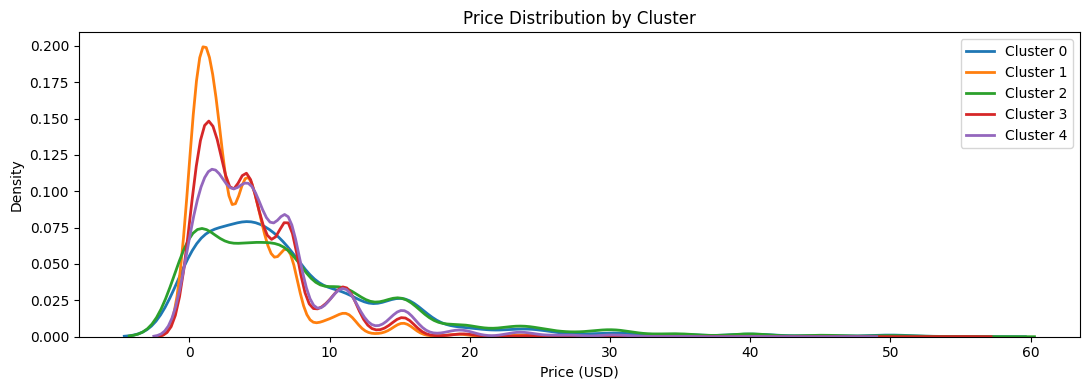

In [20]:
# Price distribution by cluster
fig, ax = plt.subplots(figsize=(11, 4))
for c in range(k):
    subset = df[(df["cluster"] == c) & (df["price"] <= 60)]["price"]
    sns.kdeplot(subset, ax=ax, label=f"Cluster {c}", color=palette[c], linewidth=2)

ax.set_xlabel("Price (USD)")
ax.set_title("Price Distribution by Cluster")
ax.legend()
plt.tight_layout()
plt.show()

## Validate

In [21]:
from sklearn.metrics import silhouette_score

# Silhouette on a held-out sample using cosine distance
np.random.seed(0)
val_idx = np.random.choice(len(feature_matrix), size=2000, replace=False)
sil = silhouette_score(feature_matrix[val_idx], df["cluster"].values[val_idx], metric="cosine")
print(f"Silhouette score (cosine, n=2000): {sil:.4f}")

Silhouette score (cosine, n=2000): 0.2223


In [22]:
# Sanity check: do well-known games land in sensible clusters?
checks = ["Counter-Strike", "Stardew Valley", "DOTA", "Terraria", "Garry"]
for name in checks:
    match = df[df["name"].str.contains(name, case=False, na=False)]
    if len(match) > 0:
        row = match.iloc[0]
        print(f"{row['name']}: cluster={row['cluster']} | tags={row['steamspy_tags'][:60]}")

Counter-Strike: cluster=0 | tags=Action;FPS;Multiplayer
Stardew Valley: cluster=2 | tags=RPG;Simulation;Pixel Graphics
Dota 2: cluster=2 | tags=Free to Play;MOBA;Strategy
Terraria: cluster=4 | tags=Sandbox;Adventure;Survival
Garry's Mod: cluster=2 | tags=Sandbox;Multiplayer;Funny


In [23]:
# Summary table
summary = []
for c in range(k):
    cdf = df[df["cluster"] == c]
    tags = []
    for row in cdf["steamspy_tags"].dropna():
        tags.extend(row.split(";"))
    top3 = ", ".join([t for t, _ in Counter(tags).most_common(3)])
    summary.append({
        "Cluster": c,
        "Size": len(cdf),
        "% Library": f"{len(cdf)/len(df)*100:.1f}%",
        "Top 3 Tags": top3,
        "Median Price": f"${cdf['price'].median():.2f}",
        "Median Pos Ratio": f"{cdf['positive_ratio'].median():.2f}"
    })

pd.DataFrame(summary)

,Cluster,Size,% Library,Top 3 Tags,Median Price,Median Pos Ratio
0,0,3649,13.5%,"Action, Adventure, Early Access",$5.54,0.67
1,1,4492,16.6%,"Casual, Indie, Strategy",$2.09,0.67
2,2,7147,26.4%,"Indie, Strategy, Simulation",$5.99,0.74
3,3,5132,19.0%,"Indie, Action, Casual",$3.99,0.71
4,4,6655,24.6%,"Adventure, Indie, Casual",$3.99,0.71
